In [1]:
from pathlib import Path
import struct
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cv_data_root_path = Path("/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data")
mnist_path = cv_data_root_path / "mnist"

In [3]:

if mnist_path.is_dir():
    print(f"Loading MNIST data from {mnist_path}")
    for item in mnist_path.iterdir():
        print(item)


Loading MNIST data from /Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/t10k-images-idx3-ubyte
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/train-labels.idx1-ubyte
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/.DS_Store
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/train-images.idx3-ubyte
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/t10k-labels-idx1-ubyte
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/train-images-idx3-ubyte
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/mnist/t10k-labels.idx1-ubyte
/

# **MNIST Dataset File Format Cheat Sheet**

MNIST is **not** stored as individual image files.

Instead, each file is a **binary file** consisting of:

```text
+----------------------+
| Header               |
+----------------------+
| Raw Data             |
+----------------------+
```

The header tells us **how to interpret** the remaining bytes.

---

# **MNIST Dataset Files**

The dataset consists of **4 files**.

| File | Contents |
|:-----|:---------|
| `train-images.idx3-ubyte` | 60,000 training images |
| `train-labels.idx1-ubyte` | Labels for training images |
| `t10k-images.idx3-ubyte` | 10,000 test images |
| `t10k-labels.idx1-ubyte` | Labels for test images |

---

# **Understanding the File Name**

Example:

```text
train-images.idx3-ubyte
```

Breakdown:

```text
train-images
        │
        └── Training images

idx3
   │
   └── 3-dimensional tensor

ubyte
    │
    └── Unsigned Byte (uint8)
```

Similarly,

```text
train-labels.idx1-ubyte
```

means

```text
idx1
 │
 └── 1-dimensional tensor
```

---

# **Image File Format (`idx3`)**

Every image file starts with a **16-byte header**.

```text
Byte 0 ───────── Byte 15

+-----------+-----------+-----------+-----------+
| Magic No. | # Images  | Rows      | Columns   |
+-----------+-----------+-----------+-----------+
    4B           4B          4B          4B
```

Each field is stored as

- **Unsigned Integer**
- **4 Bytes**
- **Big Endian**

Therefore,

```python
header = f.read(16)

magic, n_images, rows, cols = struct.unpack(">IIII", header)
```

reads the complete header.

---

## **Header Example**

For the training images,

```text
Magic Number    = 2051
Number Images   = 60000
Rows            = 28
Columns         = 28
```

---

# **Image Data**

Immediately after the header comes the pixel data.

```text
+----------------------+
| Header (16 bytes)    |
+----------------------+
| Image 1              |
| Image 2              |
| Image 3              |
| ...                  |
+----------------------+
```

Each image contains

```text
28 × 28 = 784 pixels
```

Every pixel is stored as

```text
Unsigned Byte (uint8)

↓

1 Byte
```

Pixel values range from

```text
0 → Black

255 → White
```

---

## **Total Image Data Size**

```text
60000 images

×

28 rows

×

28 cols

×

1 byte / pixel

=

47,040,000 bytes
```

Notice:

Each pixel occupies **1 byte**, **NOT 4 bytes**.

---

# **Reading Image Data**

After reading the header,

the file pointer automatically moves to the image data.

```python
pixels_bytes = f.read()
```

Now convert the raw bytes into NumPy integers:

```python
pixels = np.frombuffer(pixels_bytes, dtype=np.uint8)
```

Shape becomes

```text
(47040000,)
```

Finally reshape

```python
X = pixels.reshape(n_images, rows, cols)
```

Result

```text
(60000, 28, 28)
```

---

# **Label File Format (`idx1`)**

Label files are simpler.

They contain an **8-byte header**.

```text
+-----------+-----------+
| Magic No. | # Labels  |
+-----------+-----------+
    4B           4B
```

Read using

```python
header = f.read(8)

magic, n_labels = struct.unpack(">II", header)
```

---

## **Label Data**

Immediately after the header,

```text
+--------------------+
| Header (8 bytes)   |
+--------------------+
| Label 1            |
| Label 2            |
| Label 3            |
| ...                |
+--------------------+
```

Each label is stored as

```text
Unsigned Byte (uint8)

↓

1 Byte
```

Possible values

```text
0
1
2
...
9
```

Read using

```python
labels = np.frombuffer(f.read(), dtype=np.uint8)
```

Shape

```text
(60000,)
```

---

# **Why Use `struct` for Header?**

The header stores a **small number of integers**.

```text
2051
60000
28
28
```

Each occupies

```text
4 Bytes
```

Therefore,

```python
struct.unpack(">IIII", ...)
```

is the correct tool.

---

# **Why Use `np.frombuffer()` for Pixels?**

The image data contains

```text
47,040,000

unsigned bytes
```

Reading each byte individually with `struct.unpack()` would be slow and memory inefficient.

Instead,

```python
np.frombuffer(..., dtype=np.uint8)
```

interprets the entire byte stream directly as a NumPy array.

---

# **Mental Model**

```text
Open File

        │

        ▼

Read Header
(16 bytes / 8 bytes)

        │

        ▼

struct.unpack()

        │

        ▼

Metadata

Magic Number
# Images
Rows
Cols

        │

        ▼

Read Remaining Bytes

        │

        ▼

np.frombuffer(dtype=np.uint8)

        │

        ▼

reshape()

        │

        ▼

Images
(N, 28, 28)

or

Labels
(N,)
```

---

# **Quick Reference**

| Component | Header Size | Data Type | Tool |
|:----------|:------------|:----------|:-----|
| Image Header | 16 bytes | 4 × uint32 | `struct.unpack(">IIII")` |
| Label Header | 8 bytes | 2 × uint32 | `struct.unpack(">II")` |
| Image Data | 60000 × 28 × 28 bytes | uint8 | `np.frombuffer(..., dtype=np.uint8)` |
| Label Data | 60000 bytes | uint8 | `np.frombuffer(..., dtype=np.uint8)` |

---

# **Final Memory Rules**

1. MNIST stores **binary tensors**, **not image files**.
2. `idx3` → 3D tensor `(N, H, W)`
3. `idx1` → 1D tensor `(N,)`
4. **Header** stores metadata → use `struct.unpack()`
5. **Image/Label data** stores homogeneous bytes → use `np.frombuffer(dtype=np.uint8)`
6. Every pixel is an **unsigned byte (`uint8`)** → **1 byte per pixel**, **NOT** 4 bytes.
7. Read → `reshape()` → Ready for ML.

In [4]:
# Open Images
file_path = mnist_path / "train-images.idx3-ubyte"

with open(file_path, 'rb') as f:
    # Read first 16 bytes
    header = f.read(16)
    # Unpack the 16 bytes in 4 integers (4int X 4bytes = 16bytes)
    magic, n_images, rows, cols = struct.unpack(">IIII", header)
    # Read remaining bytes (60000 X 28 X 28 X 1)
    # num_pixels: 60000 X 28 X 28, for each pixel we use 1 byte (0 to 255)
    pixels_bytes = f.read()
    # Convert bytes to integers: np.uint8 means unsigned 8 bit int
    pixels = np.frombuffer(pixels_bytes, dtype=np.uint8)
    # Reshape pixels
    pixels = pixels.reshape(60000, 28, 28)



print(magic, n_images, rows, cols)
print(pixels.shape)

2051 60000 28 28
(60000, 28, 28)


In [5]:
sample_image = pixels[15]
print(sample_image.shape)

(28, 28)


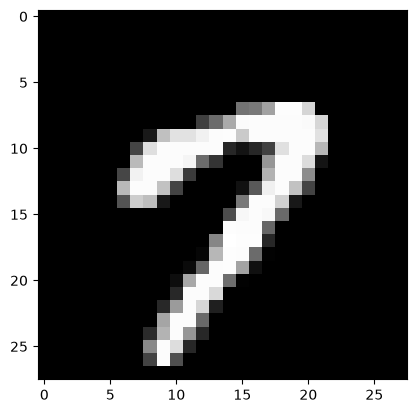

In [6]:
plt.imshow(sample_image, cmap="grey")
plt.show()

In [9]:
# Open Labels

file_path = mnist_path / "train-labels.idx1-ubyte"

with open(file_path, 'rb') as f:
    # Read first 8 bytes
    header = f.read(8)
    # Unpack the 8 bytes in 2 integers (2int X 4bytes = 8bytes)
    magic, n_images = struct.unpack(">II", header)
    # Read remaining bytes (60000 X 1)
    # num_labels: 60000, for each label we use 1 byte (0 to 255)
    labels_bytes = f.read()
    # Convert bytes to integers: np.uint8 means unsigned 8 bit int
    labels = np.frombuffer(labels_bytes, dtype=np.uint8)


print(magic, n_images)
print(labels.shape)

2049 60000
(60000,)


# **Final Function**

In [ ]:
def load_mnist_images(file_path:Path, is_test:bool=False):

    if file_path.is_file():
        if is_test:
            B=10000
        else:
            B=60000

        with open(file_path, 'rb') as f:
            header = f.read(16)
            magic, n_images, rows, cols = struct.unpack(">IIII", header)
            pixels_bytes = f.read()

        pixels = np.frombuffer(pixels_bytes, dtype=np.uint8)
        pixels = pixels.reshape(B, 28, 28)
        return pixels
    
    return None


def load_mnist_labels(file_path:Path):

    if file_path.is_file():

        with open(file_path, 'rb') as f:
            header = f.read(8)
            magic, n_images = struct.unpack(">II", header)
            labels_bytes = f.read()
        labels = np.frombuffer(labels_bytes, dtype=np.uint8)
        return labels
    
    return None



def load_mnist(folder_path):
    if folder_path.is_dir():

        train_img_file_path = folder_path / "train-images.idx3-ubyte"
        train_label_file_path = folder_path / "train-labels.idx1-ubyte"
        test_img_file_path = folder_path / "t10k-images.idx3-ubyte"
        test_label_file_path = folder_path / "t10k-labels.idx1-ubyte"

        # Train Data
        Xtr = load_mnist_images(train_img_file_path)
        Ytr = load_mnist_labels(train_label_file_path)

        # Test Data
        Xts = load_mnist_images(test_img_file_path, is_test=True)
        Yts = load_mnist_labels(test_label_file_path)

    return Xtr, Ytr, Xts, Yts


X_train, Y_train, X_test, Y_test = load_mnist(mnist_path)


print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)


(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


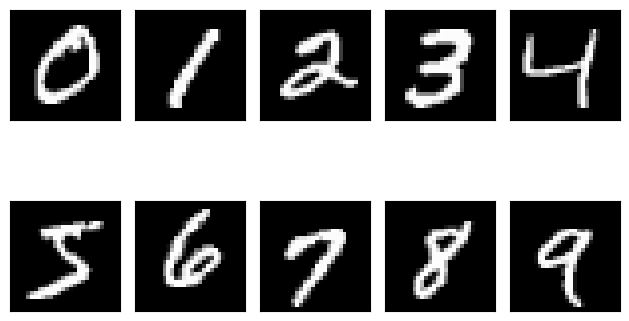

In [36]:
# plt.figure(figsize=(10, 16))
fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i in range(10):
    img = X_train[Y_train==i][0].reshape(28, 28)
    ax[i].imshow(img, cmap="grey")
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()

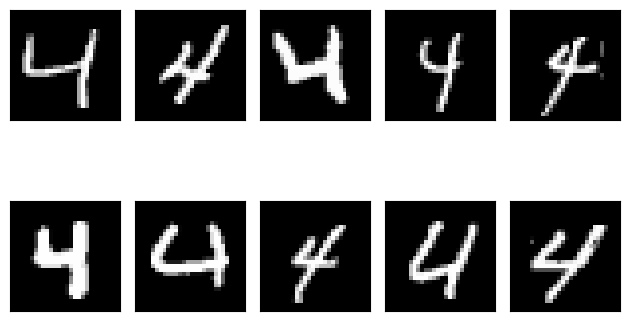

In [37]:
# plt.figure(figsize=(10, 16))
fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i in range(10):
    img = X_train[Y_train==4][i].reshape(28, 28)
    ax[i].imshow(img, cmap="grey")
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()